# Car Price Prediction System Using Machine Learning

## 1. Project Introduction

This project builds a used-car price prediction system. It cleans and prepares car data, explores important patterns, and tests two machine learning models. Linear Regression is used as the baseline model and Random Forest Regression is tested as an alternative model.

## 2. Project Objectives

- Understand the structure of the car price dataset.
- Clean and prepare the data for machine learning.
- Create simple visualizations to understand the data.
- Build Linear Regression as a baseline model.
- Build Random Forest Regression as an alternative model.
- Compare both models using regression metrics.
- Save the selected model for later Flask integration.

## 3. Import Required Libraries

- **pandas** - load and work with tabular data
- **numpy** - numerical operations
- **matplotlib / seaborn** - visualize data
- **scikit-learn** - machine learning models, train/test split, and evaluation metrics
- **pickle** - save and load the final model

In [1]:
import sys
import pandas
import numpy
import sklearn

print("Python:", sys.version)
print("Pandas:", pandas.__version__)
print("NumPy:", numpy.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]
Pandas: 3.0.3
NumPy: 2.5.1
Scikit-learn: 1.9.0


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle


## 4. Load Dataset

In [3]:
cars_data = pd.read_csv("../data/raw/Cardetails.csv")

### Display First Five Records

The `head()` function displays the first five records so we can confirm that the dataset loaded correctly.

In [4]:
cars_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


### Understand Dataset

Before cleaning or modeling, we check the dataset shape, columns, information, and basic statistics.

In [5]:
print("Shape of dataset:", cars_data.shape)
print("\nColumn names:")
print(cars_data.columns.tolist())


Shape of dataset: (8128, 13)

Column names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']


In [6]:
cars_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [7]:
cars_data.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


## 5. Data Cleaning

We remove unnecessary columns, handle missing values and duplicates, clean numeric values, and verify the final cleaned data.

### Remove Unnecessary Columns

The `torque` and `seats` columns are not used in this project, so we remove them.

In [8]:
cars_data.drop(columns=["torque", "seats"], inplace=True)
cars_data.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp


### Check Missing Values

Some rows have missing data in important columns. We check the missing-value counts before removing those rows.

In [9]:
print("Missing values before removal:")
print(cars_data.isnull().sum())

Missing values before removal:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
dtype: int64


### Remove Missing Values

We remove rows with missing data so the model receives complete records.

In [10]:
cars_data.dropna(inplace=True)
print("Shape after removing rows with missing values:", cars_data.shape)

Shape after removing rows with missing values: (7907, 11)


### Check and Remove Duplicate Rows

Duplicate rows can bias the model, so we remove them.

In [11]:
print("Duplicate rows before:", cars_data.duplicated().sum())

cars_data.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", cars_data.shape)


Duplicate rows before: 1189
Shape after removing duplicates: (6718, 11)


### Remove Units from Numeric Columns

Some columns contain numbers with text units. We remove the units before converting these columns to numeric values.

In [12]:
# Remove text units from these columns
cars_data["mileage"] = cars_data["mileage"].astype(str).str.replace(" kmpl", "", regex=False)
cars_data["mileage"] = cars_data["mileage"].astype(str).str.replace(" km/kg", "", regex=False)

cars_data["engine"] = cars_data["engine"].astype(str).str.replace(" CC", "", regex=False)

cars_data["max_power"] = cars_data["max_power"].astype(str).str.replace(" bhp", "", regex=False)


### Convert Columns to Numeric

After removing the text units, we convert the cleaned columns to numeric values.

In [13]:
# Convert cleaned columns to numeric
# errors="coerce" turns any invalid/empty values into NaN instead of crashing

cars_data["mileage"] = pd.to_numeric(cars_data["mileage"], errors="coerce")
cars_data["engine"] = pd.to_numeric(cars_data["engine"], errors="coerce")
cars_data["max_power"] = pd.to_numeric(cars_data["max_power"], errors="coerce")

### Final Data Cleaning Check

We verify the shape, missing values, duplicate rows, and data types after cleaning.

In [14]:
cars_data.dropna(inplace=True)

print("Missing values after numeric conversion and cleanup:")
print(cars_data.isnull().sum())
print("\nShape after all data cleaning:", cars_data.shape)

Missing values after numeric conversion and cleanup:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
dtype: int64

Shape after all data cleaning: (6717, 11)


In [15]:
cars_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20


In [16]:
print("Dataset Shape:", cars_data.shape)
print("\nData Types:")
print(cars_data.dtypes)
print("\nMissing Values Count:")
print(cars_data.isnull().sum())
print("\nDuplicate Rows:", cars_data.duplicated().sum())

Dataset Shape: (6717, 11)

Data Types:
name                 str
year               int64
selling_price      int64
km_driven          int64
fuel                 str
seller_type          str
transmission         str
owner                str
mileage          float64
engine             int64
max_power        float64
dtype: object

Missing Values Count:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
dtype: int64

Duplicate Rows: 0


## 6. Feature Engineering

We create useful features from the cleaned car data, including the car brand and car age.

### Extract Car Brand

The `name` column contains the full car name (e.g., `"Maruti Swift Dzire VDI"`). We extract just the brand—the first word—which is more useful for the model than the full name.

In [17]:
# Extract the brand (first word) from the full car name
cars_data["brand"] = cars_data["name"].apply(lambda x: x.split()[0])

print("Brand extraction completed.")
print("\nFirst 10 cars with their brands:")
print(cars_data[["name", "brand"]].head(10))

Brand extraction completed.

First 10 cars with their brands:
                                   name    brand
0                Maruti Swift Dzire VDI   Maruti
1          Skoda Rapid 1.5 TDI Ambition    Skoda
2              Honda City 2017-2020 EXi    Honda
3             Hyundai i20 Sportz Diesel  Hyundai
4                Maruti Swift VXI BSIII   Maruti
5         Hyundai Xcent 1.2 VTVT E Plus  Hyundai
6          Maruti Wagon R LXI DUO BSIII   Maruti
7                    Maruti 800 DX BSII   Maruti
8                      Toyota Etios VXD   Toyota
9  Ford Figo Diesel Celebration Edition     Ford


### Create Car Age

Instead of using the raw year, we create `car_age` which represents how old the car is. Older cars typically have lower prices. Using age directly makes this relationship easier for the model to learn.

In [18]:
# Create car_age feature (how many years old the car is)
current_year = 2026
cars_data["car_age"] = current_year - cars_data["year"]

print("Car age feature created.")
print("\nFirst 5 cars with their age:")
print(cars_data[["year", "car_age"]].head())

Car age feature created.

First 5 cars with their age:
   year  car_age
0  2014       12
1  2014       12
2  2006       20
3  2010       16
4  2007       19


### Verify New Features

Let's verify that the new features were created correctly.

In [19]:
# Display the dataset with new features
print("Dataset with new features (brand and car_age):")
print(cars_data.head())

Dataset with new features (brand and car_age):
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage  engine  max_power    brand  \
0  Individual       Manual   First Owner    23.40    1248      74.00   Maruti   
1  Individual       Manual  Second Owner    21.14    1498     103.52    Skoda   
2  Individual       Manual   Third Owner    17.70    1497      78.00    Honda   
3  Individual       Manual   First Owner    23.00    1396      90.00  Hyundai   
4  Individual       Manual   First Owner    16.10    1298      88.20   Maruti   

   car_age  
0 

In [20]:
# Verify name, brand, year, and car_age together
print("\nVerification: name, brand, year, and car_age (first 10 rows):")
print(cars_data[["name", "brand", "year", "car_age"]].head(10))


Verification: name, brand, year, and car_age (first 10 rows):
                                   name    brand  year  car_age
0                Maruti Swift Dzire VDI   Maruti  2014       12
1          Skoda Rapid 1.5 TDI Ambition    Skoda  2014       12
2              Honda City 2017-2020 EXi    Honda  2006       20
3             Hyundai i20 Sportz Diesel  Hyundai  2010       16
4                Maruti Swift VXI BSIII   Maruti  2007       19
5         Hyundai Xcent 1.2 VTVT E Plus  Hyundai  2017        9
6          Maruti Wagon R LXI DUO BSIII   Maruti  2007       19
7                    Maruti 800 DX BSII   Maruti  2001       25
8                      Toyota Etios VXD   Toyota  2011       15
9  Ford Figo Diesel Celebration Edition     Ford  2013       13


In [21]:
# Check missing values
print("\nMissing values after feature engineering:")
print(cars_data.isnull().sum())


Missing values after feature engineering:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
brand            0
car_age          0
dtype: int64


In [22]:
# Check data types
print("\nData types:")
print(cars_data.dtypes)


Data types:
name                 str
year               int64
selling_price      int64
km_driven          int64
fuel                 str
seller_type          str
transmission         str
owner                str
mileage          float64
engine             int64
max_power        float64
brand                str
car_age            int64
dtype: object


In [23]:
# List all columns
print("\nAll columns in the dataset:")
print(cars_data.columns.tolist())
print(f"\nTotal columns: {len(cars_data.columns)}")
print(f"Total rows: {len(cars_data)}")


All columns in the dataset:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'brand', 'car_age']

Total columns: 13
Total rows: 6717


## 7. Exploratory Data Analysis

We use a few simple graphs to understand the data and its relationship with selling price.

### Distribution of Selling Price

The selling price is our target variable. Visualizing its distribution shows how prices are spread across the dataset.

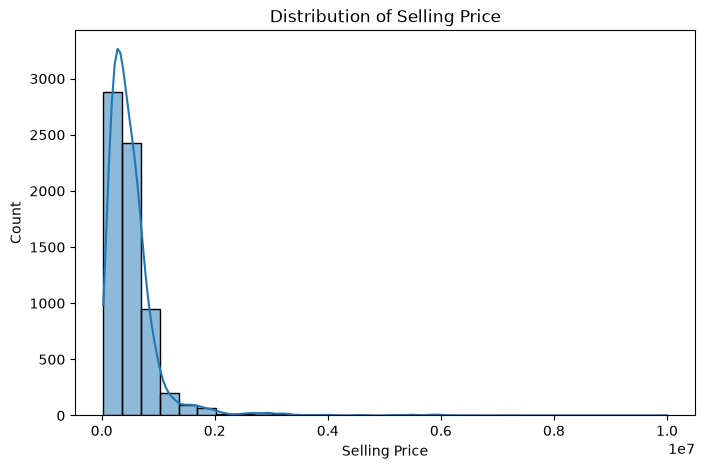

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data=cars_data, x="selling_price", bins=30, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()

### Fuel Type Distribution

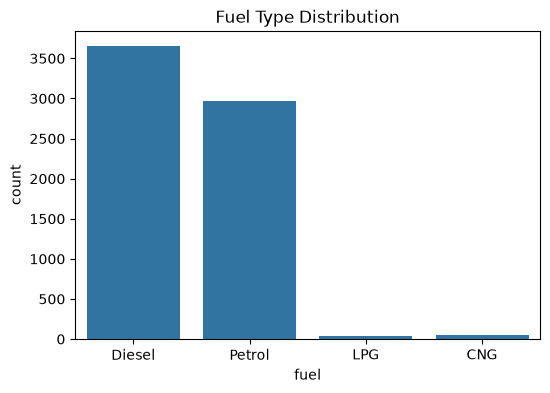

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="fuel", data=cars_data)
plt.title("Fuel Type Distribution")
plt.show()


### Transmission Type Distribution

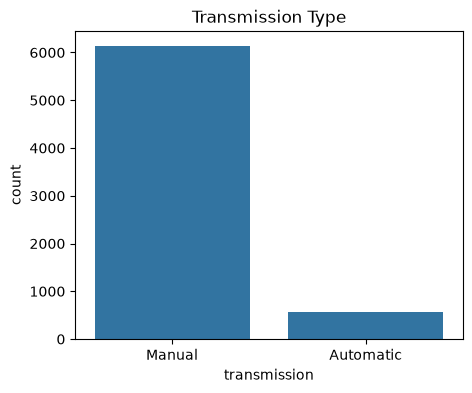

In [26]:
plt.figure(figsize=(5,4))
sns.countplot(x="transmission", data=cars_data)
plt.title("Transmission Type")
plt.show()


### Selling Price vs Car Age

Older cars are generally expected to sell for less.

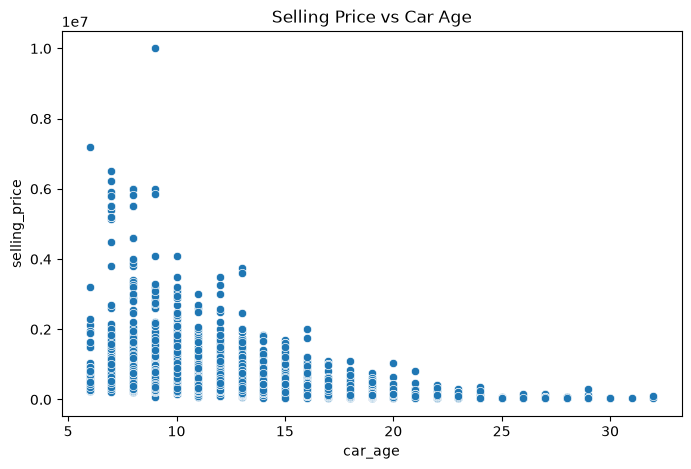

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="car_age", y="selling_price", data=cars_data)
plt.title("Selling Price vs Car Age")
plt.show()


### Selling Price vs Kilometers Driven

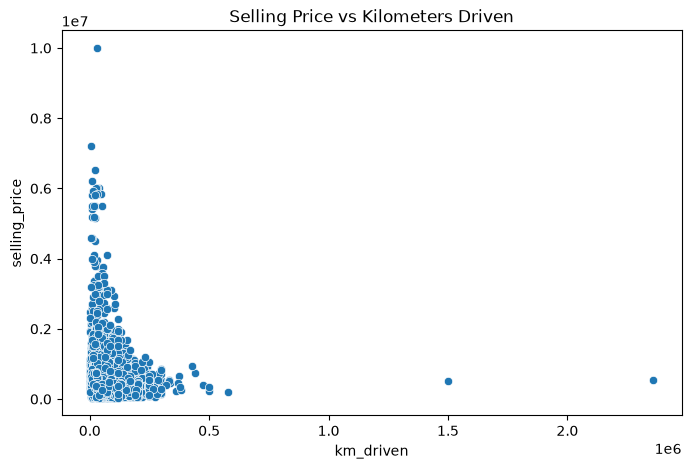

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="km_driven", y="selling_price", data=cars_data)
plt.title("Selling Price vs Kilometers Driven")
plt.show()


# Correlation Heatmap of Numerical Features

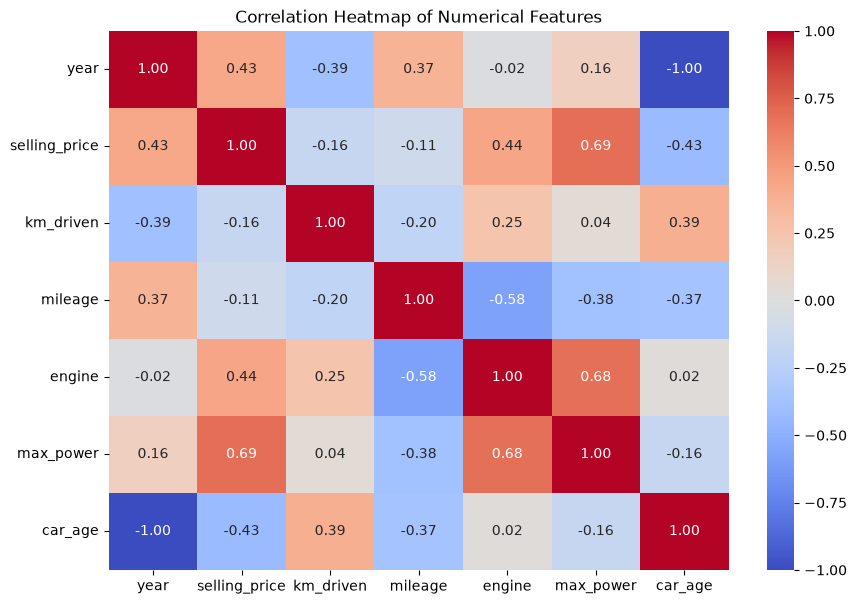

In [29]:
plt.figure(figsize=(10, 7))

correlation = cars_data.select_dtypes(include=["number"]).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The correlation heatmap shows the relationship between numerical variables in the dataset. It helps identify which numerical features have stronger or weaker relationships with the selling price.

## 8. Encode Categorical Data

Machine learning models need numeric input. We use the existing LabelEncoder approach to convert the text categories into numbers and store the encoders for later predictions.

In [30]:
categorical_cols = ["brand", "fuel", "seller_type", "transmission", "owner"]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    encoded_values = np.asarray(
        le.fit_transform(cars_data[col]),
        dtype=np.int64,
    )
    cars_data[col] = encoded_values
    encoders[col] = le

cars_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,brand,car_age
0,Maruti Swift Dzire VDI,2014,450000,145500,1,1,1,0,23.40,1248,74.00,20,12
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,1,1,1,2,21.14,1498,103.52,26,12
2,Honda City 2017-2020 EXi,2006,158000,140000,3,1,1,4,17.70,1497,78.00,10,20
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,1,1,0,23.00,1396,90.00,11,16
4,Maruti Swift VXI BSIII,2007,130000,120000,3,1,1,0,16.10,1298,88.20,20,19


## 9. Prepare Data for Machine Learning

We create `X` from the ten model features and use `selling_price` as the target `y`. The `name` column is text, and `year` is replaced by the engineered `car_age` feature, so neither is included.

In [31]:
# Remove text and duplicate age information from the model inputs
X = cars_data.drop(columns=["selling_price", "name", "year"])
y = cars_data["selling_price"]

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)
print("Input columns:", X.columns.tolist())

Input Shape : (6717, 10)
Target Shape: (6717,)
Input columns: ['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'brand', 'car_age']


In [32]:
X.head()

,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,brand,car_age
0,145500,1,1,1,0,23.40,1248,74.00,20,12
1,120000,1,1,1,2,21.14,1498,103.52,26,12
2,140000,3,1,1,4,17.70,1497,78.00,10,20
3,127000,1,1,1,0,23.00,1396,90.00,11,16
4,120000,3,1,1,0,16.10,1298,88.20,20,19


## 10. Train/Test Split

We split the data into a training set and a testing set using an 80/20 split.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)


Training Features: (5373, 10)
Testing Features : (1344, 10)
Training Labels  : (5373,)
Testing Labels   : (1344,)


## 11. Final Machine Learning Data Check

Before training the models, we verify the feature names, shape, data types, missing values, target values, train/test shapes, and feature order.

In [34]:
print("Final X columns:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("\nX data types:")
print(X.dtypes)

print("\nMissing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:", y.isnull().sum())

print("\nTrain/test shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

feature_order_matches = X_train.columns.tolist() == X_test.columns.tolist()
print("\nFeature order matches:", feature_order_matches)

print("\nFirst five rows of X_train:")
print(X_train.head())

print("\nFirst five values of y_train:")
print(y_train.head().tolist())

Final X columns:
['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'brand', 'car_age']

X shape: (6717, 10)

X data types:
km_driven         int64
fuel              int64
seller_type       int64
transmission      int64
owner             int64
mileage         float64
engine            int64
max_power       float64
brand             int64
car_age           int64
dtype: object

Missing values in X:
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
mileage         0
engine          0
max_power       0
brand           0
car_age         0
dtype: int64

Missing values in y: 0

Train/test shapes:
X_train: (5373, 10)
X_test : (1344, 10)
y_train: (5373,)
y_test : (1344,)

Feature order matches: True

First five rows of X_train:
      km_driven  fuel  seller_type  transmission  owner  mileage  engine  \
2583      80000     3            1             1      0    19.10    1197   
1428      35000     1            1

## 12. Linear Regression Model

Linear Regression is the baseline model because it is simple and easy to understand.

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


### Model Coefficients

Each feature gets a coefficient (weight):
- A **positive** coefficient means that feature increases predicted price.
- A **negative** coefficient means that feature decreases predicted price.

In [36]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients


,Feature,Coefficient
0,km_driven,-0.615739
1,fuel,-28940.488372
2,seller_type,-118263.074009
3,transmission,-336672.663490
4,owner,-13996.062078
5,mileage,3805.602929
6,engine,56.277917
7,max_power,8683.446972
8,brand,1381.567839
9,car_age,-34678.599223


### Intercept

The intercept is the baseline predicted price when all feature values are zero:

`Selling Price = (Feature1 × Coefficient1) + (Feature2 × Coefficient2) + ... + Intercept`

In [37]:
print("Intercept:", model.intercept_)

Intercept: 543932.7939885249


### Evaluate Linear Regression

We evaluate the Linear Regression model on the test data using R2 Score, MAE, and RMSE.

In [38]:
y_pred = model.predict(X_test)

### Actual vs Predicted Prices (sample)

In [39]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": np.round(y_pred, 2)
})

results.head(10)


,Actual Price,Predicted Price
0,450000,1515635.83
1,800000,697305.89
2,75000,237028.55
3,3200000,1848583.40
4,1650000,1494333.84
5,180000,17481.55
6,1019999,663766.76
7,350000,356698.99
8,722000,544127.48
9,315000,209691.14


In [40]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance")
print("-" * 30)
print("R2 Score:", round(r2, 4))
print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))


Model Performance
------------------------------
R2 Score: 0.6594
Mean Absolute Error: 168417.9
Root Mean Squared Error: 273376.79


### Visualize Actual vs Predicted Prices

If the model performs well, the points should fall close to the red diagonal line (which represents a perfect prediction).

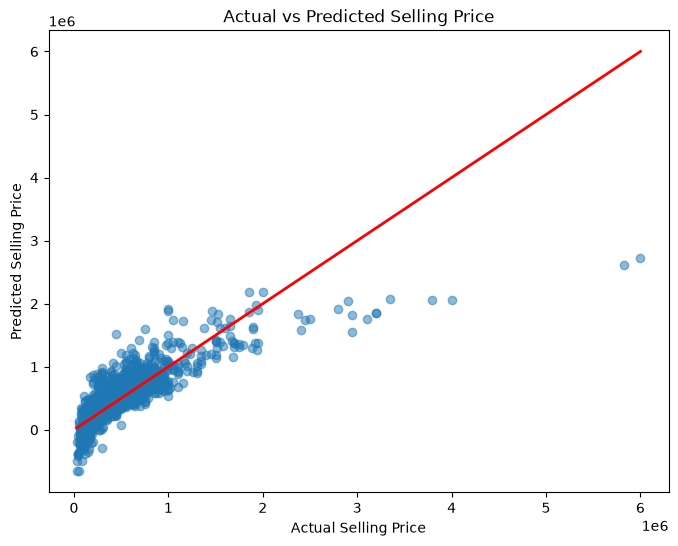

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()


## 13. Random Forest Regression

Random Forest uses multiple decision trees and can learn more complex relationships between the input features and selling price. It is tested as an alternative to the Linear Regression baseline.

### Evaluate Random Forest

We calculate R2 Score, Mean Absolute Error, and Root Mean Squared Error for the Random Forest model.

In [42]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

# Make predictions
random_forest_predictions = random_forest_model.predict(X_test)

# Calculate model performance
random_forest_r2 = r2_score(y_test, random_forest_predictions)
random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))

print("\nRandom Forest Model Performance")
print("------------------------------")
print("R2 Score               :", round(random_forest_r2, 4))
print("Mean Absolute Error    :", round(random_forest_mae, 2))
print("Root Mean Squared Error:", round(random_forest_rmse, 2))

random_forest_results = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": np.round(random_forest_predictions[:10], 2)
})

print("\nFirst 10 Random Forest Predictions")
random_forest_results

Random Forest trained successfully!

Random Forest Model Performance
------------------------------
R2 Score               : 0.9202
Mean Absolute Error    : 76566.56
Root Mean Squared Error: 132301.08

First 10 Random Forest Predictions


,Actual Price,Predicted Price
0,450000,1604239.99
1,800000,724350.00
2,75000,248879.99
3,3200000,3005049.99
4,1650000,1650569.98
5,180000,129950.00
6,1019999,1068958.28
7,350000,381069.98
8,722000,811755.00
9,315000,264554.16


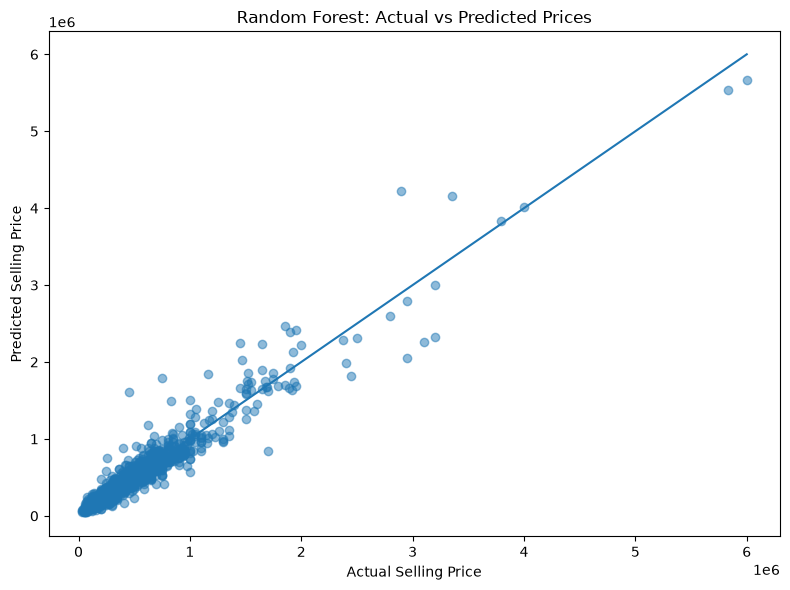

In [43]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, random_forest_predictions, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest: Actual vs Predicted Prices")

plt.tight_layout()
plt.show()

# Random Forest Prediction Error Plot

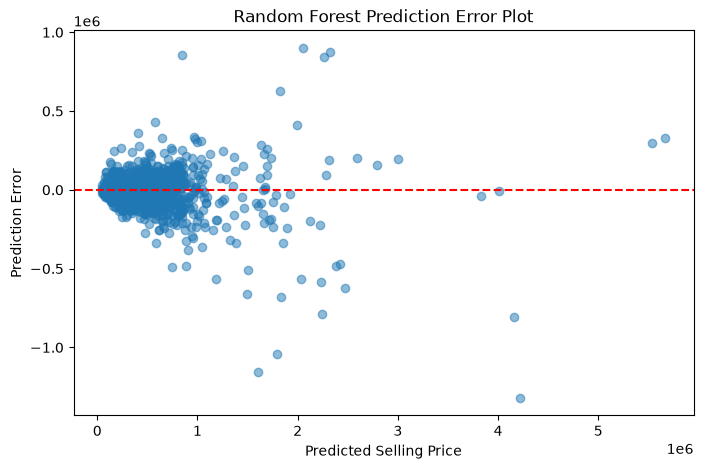

In [44]:
random_forest_errors = y_test - random_forest_predictions

plt.figure(figsize=(8, 5))

plt.scatter(random_forest_predictions, random_forest_errors, alpha=0.5)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Selling Price")
plt.ylabel("Prediction Error")
plt.title("Random Forest Prediction Error Plot")

plt.show()

This plot shows the difference between the actual and predicted car prices. The horizontal line at zero represents perfect prediction. Points closer to zero indicate smaller prediction errors.

## 14. Model Comparison

The two models are compared using the already calculated R2 Score, MAE, and RMSE values. Higher R2 is better, while lower MAE and RMSE are better.

In [45]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [r2, random_forest_r2],
    "MAE": [mae, random_forest_mae],
    "RMSE": [rmse, random_forest_rmse]
})

model_comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.659415,168417.895323,273376.788856
1,Random Forest,0.920232,76566.559490,132301.084874


In [46]:
random_forest_is_better = (
    random_forest_r2 > r2
    and random_forest_mae < mae
    and random_forest_rmse < rmse
)

if random_forest_is_better:
    print("Random Forest performs better than Linear Regression.")
    print("It has a higher R2 Score and lower MAE and RMSE.")
else:
    print("Random Forest does not perform better on all three metrics.")

Random Forest performs better than Linear Regression.
It has a higher R2 Score and lower MAE and RMSE.


The model with the higher R2 Score and lower MAE and RMSE performs better. The conclusion below is based on the actual metric values calculated above.

# Performance Comparison of Linear Regression and Random Forest

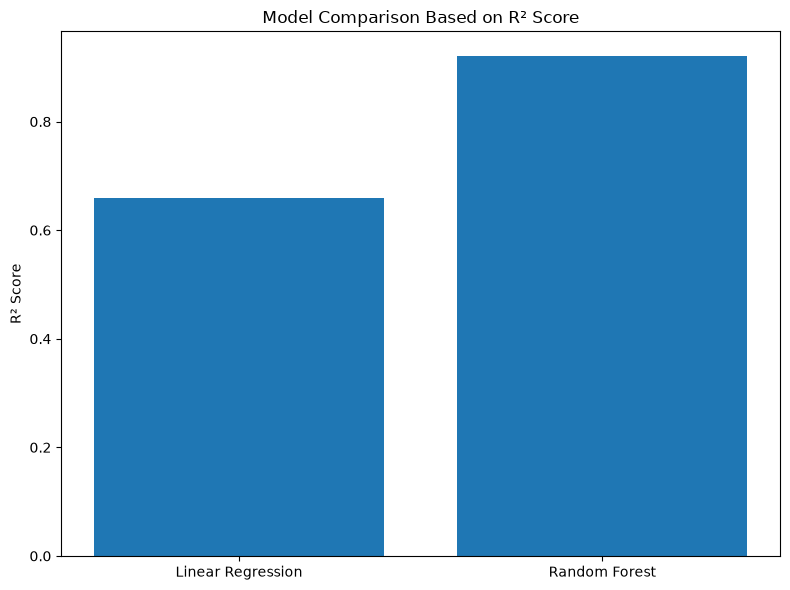

In [47]:
models = ["Linear Regression", "Random Forest"]

r2_values = [r2, random_forest_r2]

plt.figure(figsize=(8, 6))

plt.bar(models, r2_values)

plt.ylabel("R² Score")
plt.title("Model Comparison Based on R² Score")

plt.tight_layout()
plt.show()

This figure compares the R² scores of Linear Regression and Random Forest. A higher R² score indicates better ability of the model to explain variations in car selling prices. The comparison supports the selection of Random Forest as the final model.

# Performance Comparison of Linear Regression and Random Forest

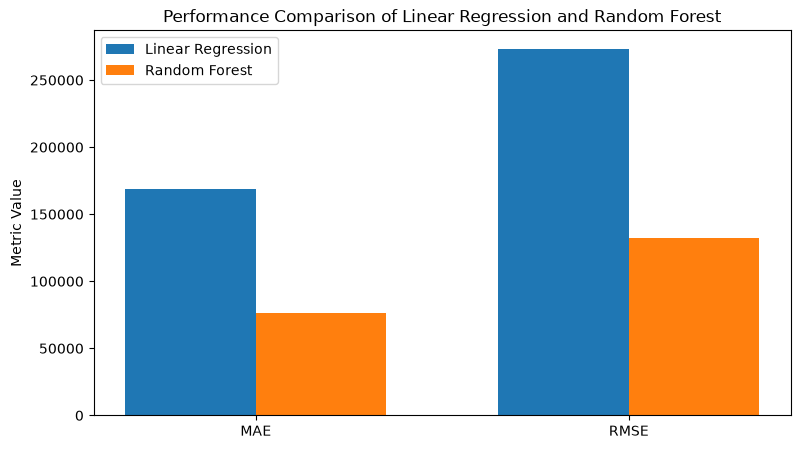

In [48]:
metrics = [ "MAE", "RMSE"]

linear_values = [ mae, rmse]
random_forest_values = [random_forest_mae, random_forest_rmse]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, linear_values, width, label="Linear Regression")
plt.bar(x + width/2, random_forest_values, width, label="Random Forest")

plt.xticks(x, metrics)
plt.ylabel("Metric Value")
plt.title("Performance Comparison of Linear Regression and Random Forest")
plt.legend()

plt.show()

This figure compares the performance of Linear Regression and Random Forest using R² Score, MAE, and RMSE. Random Forest is selected as the final model because it provides better overall performance based on the evaluation metrics.

## 15. Select Final Model

Random Forest is selected as the final model because it currently has the higher R2 Score and lower MAE and RMSE.

In [49]:
final_model = random_forest_model
print("Final model selected: Random Forest Regression")

Final model selected: Random Forest Regression


# Random Forest Feature Importance

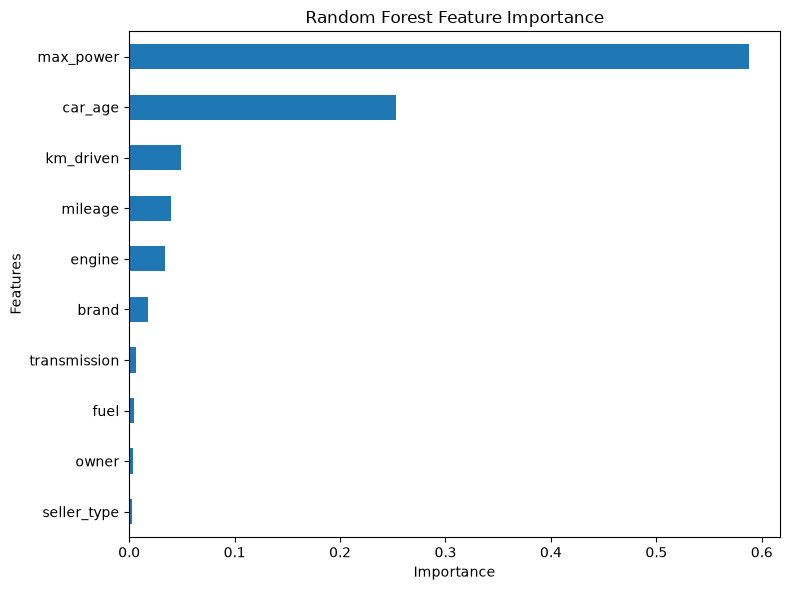

In [50]:
importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))

importance.plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

This figure shows the relative importance of the features used by the Random Forest model. Features with higher importance contributed more to the model's price prediction. The figure helps explain which vehicle characteristics were more useful in predicting the selling price.

## 16. Save Final Model

The selected Random Forest model, the encoders, and the feature list are saved together so the model can be used later.

In [51]:
model_data = {
    "model": final_model,
    "encoders": encoders,
    "features": X.columns.tolist()
}

# Save the final model and required information
with open("../models/car_price_model.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Final model saved as ../models/car_price_model.pkl")

Final model saved as ../models/car_price_model.pkl


## 17. Test Saved Model

The saved model is tested using a sample car. The categorical values are converted using the same LabelEncoders used during training, and the features are arranged in the same order before making the prediction.

In [52]:
from typing import Any

# Categorical columns used during training
categorical_cols = [
    "brand",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

# Load saved model
with open("../models/car_price_model.pkl", "rb") as file:
    saved_model_data = pickle.load(file)

saved_model = saved_model_data["model"]
saved_encoders = saved_model_data["encoders"]
saved_features = saved_model_data["features"]

print("Pickle loaded successfully.")
print("Encoders loaded successfully:", isinstance(saved_encoders, dict))
print("Saved features:", saved_features)

# Create a sample car using human-readable values
new_car: dict[str, Any] = {
    "brand": "Maruti",
    "km_driven": 50000,
    "fuel": "Petrol",
    "seller_type": "Individual",
    "transmission": "Manual",
    "owner": "First Owner",
    "mileage": 22.5,
    "engine": 1248,
    "max_power": 74.0,
    "car_age": 6
}

# Apply the same encoders used during training
for column in categorical_cols:
    encoded_value = saved_encoders[column].transform([new_car[column]])[0]
    new_car[column] = int(encoded_value)

input_data = pd.DataFrame([new_car])[saved_features]
predicted_price = saved_model.predict(input_data)[0]

print("Estimated selling price:", round(predicted_price, 2))

Pickle loaded successfully.
Encoders loaded successfully: True
Saved features: ['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'brand', 'car_age']
Estimated selling price: 679195.0


## 18. Project Conclusion

This project predicts used-car selling prices after cleaning the data, removing duplicates and missing values, converting numeric columns, creating `brand` and `car_age`, and encoding categorical data. Linear Regression was tested as the baseline model and Random Forest Regression was tested as an alternative model. Random Forest performed better, so it was selected as the final model and saved with its encoders and feature list. The saved model is ready for later Flask integration.

The saved Random Forest model successfully accepts the processed sample input and returns an estimated selling price. This confirms that the model is ready to be connected to the Flask application.